In [20]:
import numpy as np
import pandas as pd

# For path manipulation
import os #

# For visualization
import matplotlib.pyplot as plt

import torch
from torch import nn, optim

In [3]:
base_dir = './plantvillage dataset/'

In [4]:
# List sub-folders in the main directory
subfolders = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# Initialize dictionary to store data: {sub_subfolder: [file counts per subfolder]}
data = {}

# Iterate over each subfolder
for subc in subfolders:
    subc_path = os.path.join(base_dir, subc)
    # List sub-sub-folders
    sub_subs = [d for d in os.listdir(subc_path) if os.path.isdir(os.path.join(subc_path, d))]
    for sub_sub in sub_subs:
        sub_sub_path = os.path.join(subc_path, sub_sub)
        # Count files in each sub-sub-folder
        files = [f for f in os.listdir(sub_sub_path) if os.path.isfile(os.path.join(sub_sub_path, f))]
        if sub_sub not in data:
            data[sub_sub] = []
        data[sub_sub].append(len(files))

# Sort the sub-sub-folders
sub_subs_sorted = sorted(data.keys())

In [5]:
# List to store the names of classes with discrepancies
discrepant_classes = []

# Check if each sub-sub-folder has the same number of files across all sub-folders
all_match = True

for sub_sub in sub_subs_sorted:
    file_counts = data[sub_sub]
    # Verify if all counts are the same
    if len(set(file_counts)) != 1:
        print(f"Mismatch found in class: {sub_sub}")
        discrepant_classes.append(sub_sub)  # Save class with discrepancy
        all_match = False

if all_match:
    print("For each class, all sub-folders have the same number of files.")

Mismatch found in class: Grape___Esca_(Black_Measles)


In [6]:
def dataset_folderpath(dataset_name):
    return base_dir + dataset_name + '/'

# List files in each folder
files_folder1 = set(os.listdir(dataset_folderpath('color/' + discrepant_classes[0])))
files_folder2 = set(os.listdir(dataset_folderpath('segmented/' + discrepant_classes[0])))

# Create a set for filenames without extension or suffix
mask_suffix = '_final_masked'

files_folder2_without_mask = set()

for filename in files_folder2:
    # Remove the extension
    base_name, ext = os.path.splitext(filename)
    # Remove the suffix
    base_name = base_name[:-len(mask_suffix)]
    files_folder2_without_mask.add(base_name)

files_folder1_names = set()
for filename in files_folder1:
    name, ext = os.path.splitext(filename)
    files_folder1_names.add(name)

# Count matches
matches = files_folder1_names.intersection(files_folder2_without_mask)
non_matches = files_folder1_names.symmetric_difference(files_folder2_without_mask)

print(f"Number of files with the same name: {len(matches)}")
print(f"Number of files without a match: {len(non_matches)}")
print('')

non_matching_files = [filename for filename in non_matches]
print("Files in folder2 with no corresponding match in folder1:")
for filename in non_matches:
    print(filename)

Number of files with the same name: 1383
Number of files without a match: 1

Files in folder2 with no corresponding match in folder1:
7e1fd9b9-1fd9-4f98-93f5-8cf9ebc60dd9___FAM_B.Msls 4430


In [7]:
from torchvision import datasets

# Cargar los diferentes datasets
dataset_color = datasets.ImageFolder(root = dataset_folderpath('color'))
dataset_gray = datasets.ImageFolder(root = dataset_folderpath('grayscale'))
dataset_seg = datasets.ImageFolder(root = dataset_folderpath('segmented'))

In [8]:
nclasses = len(dataset_color.classes)
class_names = dataset_color.classes

print("La cantidad de clases es: ", nclasses)
print("Las clases son: ", class_names)
print("Índice a Clase: ", dataset_color.class_to_idx)

La cantidad de clases es:  38
Las clases son:  ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mite

In [9]:
import random
from torchvision.transforms import v2           # usamos v2 porque es más rápido y presenta más capacidades

# Create a dictionary to store the image tensors by folder
img_data = {}
for img_path, label in dataset_color.samples:
    folder_name = dataset_color.classes[label]  # Gets the folder name from the dataset
    if folder_name not in img_data:
        img_data[folder_name] = []
    img_data[folder_name].append(img_path)

# Define the transformation
ToTensor_transform = v2.Compose([                   # Replace v1.ToTensor(): Convert images to tensor between [0,1]
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [10]:
from torch.utils.data import Dataset

class TransformDataset(Dataset):
    def __init__(self, datasets_list, seed=42, transform=None,
                 species_mapping=None, health_mapping=None):
        self.datasets = datasets_list
        self.length = len(self.datasets[0])  # Assume all datasets have same length
        self.seed = seed
        self.transform = transform
        self.species_mapping = species_mapping
        self.health_mapping = health_mapping

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        idx = int(idx)
        import random
        random.seed(self.seed + idx)
        chosen_dataset = random.choice(self.datasets)
        image, label_idx = chosen_dataset[idx]
        # Apply transformation if exists
        if self.transform:
            image = self.transform(image)
        # Map label to species and health status
        class_name_full = chosen_dataset.classes[label_idx]
        # Extract species from class name
        species_name = class_name_full.split("___")[0]
        # Map to species ID if mapping provided
        species_id = self.species_mapping[species_name] if self.species_mapping else species_name
        # Map to health status ID
        health_id = self.health_mapping[class_name_full]
        # Return image and label dictionary
        return image, {"species": species_id, "health": health_id}

# Generate mappings for species and health status:
species_names = set([name.split("___")[0] for name in class_names])
species_mapping = {name: idx for idx, name in enumerate(sorted(species_names))}

# For health status
health_mapping = {
    class_name: 0 if '__healthy' in class_name else 1
    for class_name in class_names
}

# Crear tu nuevo dataset con etiquetas convertidas
rnd_seed = 42
dataset = TransformDataset([dataset_color, dataset_gray, dataset_seg],
                           seed=rnd_seed,
                           transform=ToTensor_transform,
                           species_mapping=species_mapping,
                           health_mapping=health_mapping)

ndata = len(dataset)

In [11]:
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit

def proportional_dataset(transform_dataset):
    base_dataset = transform_dataset.datasets[0]  # Suponemos que todos los datasets tienen misma estructura
    combined_labels = []

    for i in range(len(base_dataset)):
        path, label_idx = base_dataset.samples[i]  # ← .samples sí existe en ImageFolder
        class_name = base_dataset.classes[label_idx]  # Ejemplo: "Apple___healthy"
        species = class_name.split("___")[0]
        health = 'healthy' if 'healthy' in class_name else 'diseased'
        combined_label = f"{species}___{health}"
        combined_labels.append(combined_label)

    combined_labels = np.array(combined_labels)

    # Proporciones deseadas
    train_frac, val_frac, test_frac = 0.6, 0.2, 0.2

    # Primer split: train+val vs test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=42)
    train_val_idx, test_idx = next(sss1.split(np.zeros(len(combined_labels)), combined_labels))

    # Segundo split: train vs val
    combined_labels_train_val = combined_labels[train_val_idx]
    val_size = val_frac / (train_frac + val_frac)

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=42)
    train_idx_rel, val_idx_rel = next(sss2.split(np.zeros(len(combined_labels_train_val)), combined_labels_train_val))

    train_idx = train_val_idx[train_idx_rel]
    val_idx = train_val_idx[val_idx_rel]

    # Crear subsets del TransformDataset completo
    train_dataset = Subset(transform_dataset, train_idx)
    val_dataset = Subset(transform_dataset, val_idx)
    test_dataset = Subset(transform_dataset, test_idx)

    return train_dataset, val_dataset, test_dataset



pro_train, pro_test, pro_val = proportional_dataset(dataset)

In [12]:
from collections import Counter, defaultdict

def analyze_distribution_across_splits(train_set, val_set, test_set, base_dataset):
    def get_labels(subset):
        indices = subset.indices if hasattr(subset, 'indices') else range(len(subset))
        labels = []
        for idx in indices:
            _, label_idx = base_dataset.samples[idx]
            class_name = base_dataset.classes[label_idx]
            species = class_name.split("___")[0]
            health = 'healthy' if 'healthy' in class_name else 'diseased'
            combined = f"{species}___{health}"
            labels.append(combined)
        return labels

    # Obtener los labels por subset
    train_labels = get_labels(train_set)
    val_labels = get_labels(val_set)
    test_labels = get_labels(test_set)

    # Contar ocurrencias
    total_counter = Counter(train_labels + val_labels + test_labels)
    train_counter = Counter(train_labels)
    val_counter = Counter(val_labels)
    test_counter = Counter(test_labels)

    # Mostrar porcentaje por clase
    print(f"{'Clase':30} | Train % | Val % | Test % | Total")
    print("-" * 65)
    for cls in sorted(total_counter.keys()):
        total = total_counter[cls]
        train_pct = 100 * train_counter[cls] / total
        val_pct = 100 * val_counter[cls] / total
        test_pct = 100 * test_counter[cls] / total
        print(f"{cls:30} | {train_pct:7.1f}% | {val_pct:6.1f}% | {test_pct:7.1f}% | {total}")

In [13]:
base_dataset = dataset.datasets[0]  # el ImageFolder base
analyze_distribution_across_splits(pro_train, pro_test, pro_val, base_dataset)

Clase                          | Train % | Val % | Test % | Total
-----------------------------------------------------------------
Apple___diseased               |    60.0% |   20.0% |    20.0% | 1526
Apple___healthy                |    60.0% |   20.0% |    20.0% | 1645
Blueberry___healthy            |    60.0% |   20.0% |    20.0% | 1502
Cherry_(including_sour)___diseased |    60.1% |   20.0% |    20.0% | 1052
Cherry_(including_sour)___healthy |    60.0% |   20.0% |    20.0% | 854
Corn_(maize)___diseased        |    60.0% |   20.0% |    20.0% | 2690
Corn_(maize)___healthy         |    60.0% |   20.1% |    20.0% | 1162
Grape___diseased               |    60.0% |   20.0% |    20.0% | 3639
Grape___healthy                |    59.8% |   20.1% |    20.1% | 423
Orange___diseased              |    60.0% |   20.0% |    20.0% | 5507
Peach___diseased               |    60.0% |   20.0% |    20.0% | 2297
Peach___healthy                |    60.0% |   20.0% |    20.0% | 360
Pepper,_bell___diseased 

In [14]:
def get_set_normalize_params(dataset, batch_size=64, seed=42):

    # get a random sample
    random.seed(seed)
    sample_indices = random.sample(range(len(dataset)), batch_size)

    all_pixels = []

    for idx in sample_indices:
        img, _ = dataset[idx]
        img = ToTensor_transform(img)
        all_pixels.append(img.reshape(-1))

    # Concatenar los píxeles del batch
    all_pixels_tensor = torch.cat(all_pixels)

    # Calcular media y std
    mean = all_pixels_tensor.mean().item()
    std = all_pixels_tensor.std().item()

    print(f'Media: {mean:.2g}')
    print(f'Desviación estándar: {std:.2g}')

    return mean, std

# Cargar el conjunto de entrenamiento sin aplicar transform (para calculo de mean y std)
# Consideramos diferentes batchs
mean_std = []
batch_list = [64, 128, 256, 512]
for bsize in batch_list:
    print(f'Batch size: {bsize}')
    mean_std.append(get_set_normalize_params(pro_train, batch_size = bsize))
    print("")

# Recover las value
mean = mean_std[-1][0]
std = mean_std[-1][1]

Batch size: 64
Media: 0.38
Desviación estándar: 0.23

Batch size: 128
Media: 0.39
Desviación estándar: 0.24

Batch size: 256
Media: 0.38
Desviación estándar: 0.25

Batch size: 512
Media: 0.38
Desviación estándar: 0.24



In [15]:
# Definir transformaciones
# Transformación a todas las imagenes
in_width = 256
in_height = 256
transform = v2.Compose([
    v2.Resize((in_width, in_height)),                           # Resize images (just in case)
    ToTensor_transform,                                         # Convert to Tensor
    v2.Normalize(mean=[mean], std=[std]),                       # Normalize channel
    ])

In [16]:
batch_size = 32

# Cargamos los sets
train_loader = torch.utils.data.DataLoader(pro_train, batch_size = batch_size, shuffle = True)
val_loader = torch.utils.data.DataLoader(pro_val, batch_size = batch_size, shuffle = False)
test_loader = torch.utils.data.DataLoader(pro_test, batch_size = batch_size, shuffle = False)

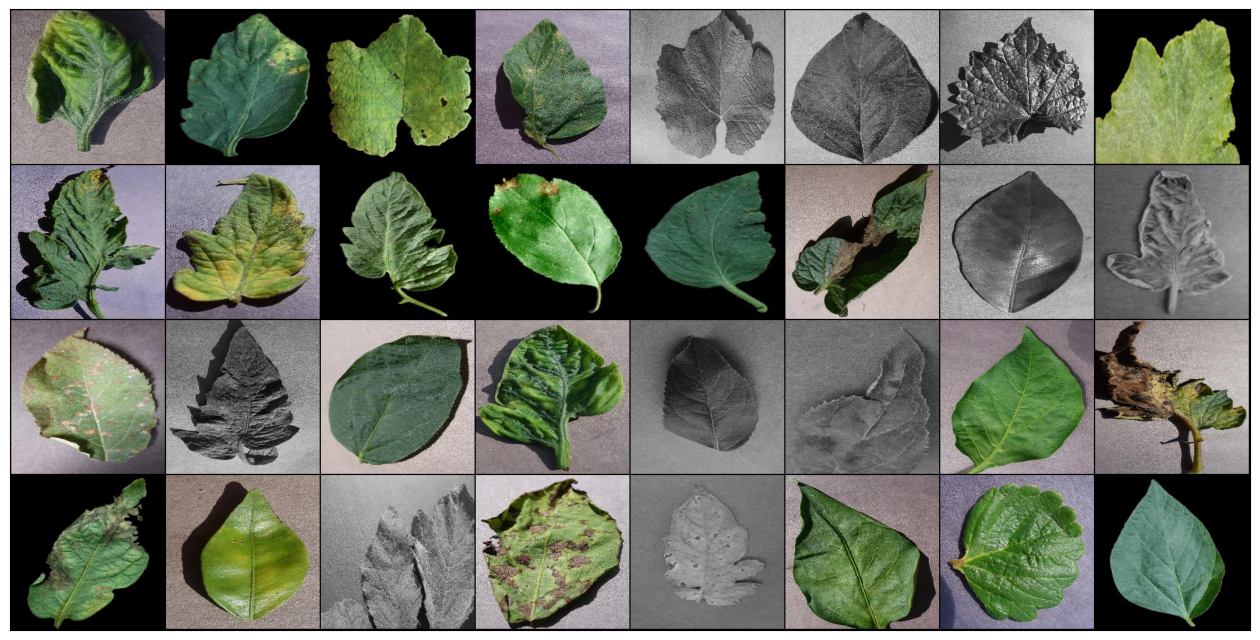

In [17]:
from torchvision.utils import make_grid

def show_batch(dl):
    """Plot images grid of single batch"""
    for images, labels in dl:
        fig,ax = plt.subplots(figsize = (16,12))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images,nrow=8).permute(1,2,0))
        break

show_batch(train_loader)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [22]:
num_classes = len(train_loader.dataset.dataset.species_mapping) # Ajusta si es necesari

In [ ]:
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Entrada RGB 3 canales
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28x28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Funciones de entrenamiento y evaluación como antes
from tqdm import tqdm  # importa tqdm

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)  # barra de progreso
    for inputs, labels in loop:
        inputs = inputs.to(device)
        labels = labels["species"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += inputs.size(0)

        # Actualiza la barra de progreso con métricas
        loop.set_postfix(loss=running_loss/total, acc=running_corrects.double().item()/total)

    return running_loss / total, running_corrects.double() / total

def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    loop = tqdm(loader, desc="Evaluating", leave=False)  # barra de progreso
    with torch.no_grad():
        for inputs, labels in loop:
            inputs = inputs.to(device)
            labels = labels["species"].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

            # Actualiza la barra de progreso con métricas
            loop.set_postfix(loss=running_loss/total, acc=running_corrects.double().item()/total)

    return running_loss / total, running_corrects.double() / total

# Entrenar por ejemplo 10 epochs
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

# Evaluación en test
test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print(f"Test loss: {test_loss:.4f} accuracy: {test_acc:.4f}")

Se presenta los datos de estsa manera porque esta NN en particulara se entreno en colab.

Epoch 1/10 | Train loss: 1.2457 acc: 0.6092 | Val loss: 0.5329 acc: 0.8264
Epoch 2/10 | Train loss: 0.5232 acc: 0.8306 | Val loss: 0.3234 acc: 0.8971
Epoch 3/10 | Train loss: 0.3106 acc: 0.8984 | Val loss: 0.2940 acc: 0.9052
Epoch 4/10 | Train loss: 0.2103 acc: 0.9309 | Val loss: 0.2552 acc: 0.9179
Epoch 5/10 | Train loss: 0.1488 acc: 0.9501 | Val loss: 0.2084 acc: 0.9349
Epoch 6/10 | Train loss: 0.1172 acc: 0.9607 | Val loss: 0.2332 acc: 0.9367
Epoch 7/10 | Train loss: 0.0954 acc: 0.9684 | Val loss: 0.2290 acc: 0.9419
Epoch 8/10 | Train loss: 0.0861 acc: 0.9713 | Val loss: 0.1977 acc: 0.9478
Epoch 9/10 | Train loss: 0.0759 acc: 0.9755 | Val loss: 0.2426 acc: 0.9460
Epoch 10/10 | Train loss: 0.0747 acc: 0.9754 | Val loss: 0.3328 acc: 0.9252

In [35]:
First_try_loss   = [0.5329, 0.3234, 0.2940, 0.2552, 0.2084, 0.2332, 0.2290, 0.1977, 0.2426, 0.3328, 0.3475]
First_try_acc    = [0.8264, 0.8971, 0.9052, 0.9179, 0.9349, 0.9367, 0.9419, 0.9478, 0.9460, 0.9252, 0.9215]

In [23]:
class ResNetBlock(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):

        shortcut = x
        x = torch.relu(self.conv1(x))
        x = self.conv2(x)
        x = shortcut + x
        x = torch.relu(x)
        return x

class ResNetBlockLineal(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.layer1 = torch.nn.Linear(in_features, out_features)
        self.layer2 = torch.nn.Linear(in_features, out_features)

    def forward(self, x):

        shortcut = x
        x = torch.relu(self.layer1(x))
        x = self.layer2(x)
        x = shortcut + x
        x = torch.relu(x)
        return x

class ResnetModel(nn.Module):
    def __init__(self, num_classes):
        super(ResnetModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Entrada RGB 3 canales
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 112x112
            ResNetBlock(32),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 56x56
            ResNetBlock(64),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28x28
            ResNetBlock(128),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16 * 16, 512),
            ResNetBlockLineal(512, 512),
            nn.ReLU(),
            #nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

modelRes = ResnetModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizerRes = optim.Adam(modelRes.parameters(), lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0)

In [24]:
from tqdm import tqdm  # importa tqdm

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)  # barra de progreso
    for inputs, labels in loop:
        inputs = inputs.to(device)
        labels = labels["species"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += inputs.size(0)

        # Actualiza la barra de progreso con métricas
        loop.set_postfix(loss=running_loss/total, acc=running_corrects.double().item()/total)

    return running_loss / total, running_corrects.double() / total

def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    loop = tqdm(loader, desc="Evaluating", leave=False)  # barra de progreso
    with torch.no_grad():
        for inputs, labels in loop:
            inputs = inputs.to(device)
            labels = labels["species"].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

            # Actualiza la barra de progreso con métricas
            loop.set_postfix(loss=running_loss/total, acc=running_corrects.double().item()/total)

    return running_loss / total, running_corrects.double() / total

Resnet_loss_history = []
Resnet_acc_history = []
# Entrenar por ejemplo 10 epochs
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(modelRes, train_loader, optimizerRes, criterion)
    val_loss, val_acc = eval_epoch(modelRes, val_loader, criterion)
    Resnet_loss_history.append(val_loss)
    Resnet_acc_history.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

# Evaluación en test
test_loss, test_acc = eval_epoch(modelRes, test_loader, criterion)
print(f"Test loss: {test_loss:.4f} accuracy: {test_acc:.4f}")

Epoch 1/10 | Train loss: 1.4107 acc: 0.5647 | Val loss: 0.6137 acc: 0.8083


Epoch 2/10 | Train loss: 0.3565 acc: 0.8821 | Val loss: 0.3238 acc: 0.8954


Epoch 3/10 | Train loss: 0.1224 acc: 0.9584 | Val loss: 0.2569 acc: 0.9222


Epoch 4/10 | Train loss: 0.0563 acc: 0.9812 | Val loss: 0.3082 acc: 0.9190


Epoch 5/10 | Train loss: 0.0482 acc: 0.9844 | Val loss: 0.3021 acc: 0.9298


...

Epoch 7/10 | Train loss: 0.0349 acc: 0.9882 | Val loss: 0.2837 acc: 0.9341


Epoch 8/10 | Train loss: 0.0255 acc: 0.9921 | Val loss: 0.4494 acc: 0.9098


Epoch 9/10 | Train loss: 0.0299 acc: 0.9907 | Val loss: 0.4343 acc: 0.9104


Epoch 10/10 | Train loss: 0.0258 acc: 0.9914 | Val loss: 0.5168 acc: 0.9091


Test loss: 0.4780 accuracy: 0.9122


In [ ]:
#torch.save(modelRes.state_dict(), "modelo_entrenado.pth")

In [27]:
from tqdm import tqdm  # importa tqdm

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)  # barra de progreso
    for inputs, labels in loop:
        inputs = inputs.to(device)
        labels = labels["health"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += inputs.size(0)

        # Actualiza la barra de progreso con métricas
        loop.set_postfix(loss=running_loss/total, acc=running_corrects.double().item()/total)

    return running_loss / total, running_corrects.double() / total

def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    loop = tqdm(loader, desc="Evaluating", leave=False)  # barra de progreso
    with torch.no_grad():
        for inputs, labels in loop:
            inputs = inputs.to(device)
            labels = labels["health"].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

            # Actualiza la barra de progreso con métricas
            loop.set_postfix(loss=running_loss/total, acc=running_corrects.double().item()/total)

    return running_loss / total, running_corrects.double() / total

Resnet_loss_history = []
Resnet_acc_history = []
# Entrenar por ejemplo 10 epochs
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(modelRes, train_loader, optimizerRes, criterion)
    val_loss, val_acc = eval_epoch(modelRes, val_loader, criterion)
    Resnet_loss_history.append(val_loss)
    Resnet_acc_history.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

# Evaluación en test
test_loss, test_acc = eval_epoch(modelRes, test_loader, criterion)
print(f"Test loss: {test_loss:.4f} accuracy: {test_acc:.4f}")

Epoch 1/10 | Train loss: 0.5266 acc: 0.7905 | Val loss: 0.3207 acc: 0.8624


Epoch 2/10 | Train loss: 0.2484 acc: 0.8991 | Val loss: 0.3146 acc: 0.8694


Epoch 3/10 | Train loss: 0.1524 acc: 0.9387 | Val loss: 0.1750 acc: 0.9290


Epoch 4/10 | Train loss: 0.0934 acc: 0.9650 | Val loss: 0.1692 acc: 0.9379


Epoch 5/10 | Train loss: 0.0542 acc: 0.9801 | Val loss: 0.1466 acc: 0.9493


...

Epoch 7/10 | Train loss: 0.0250 acc: 0.9917 | Val loss: 0.2514 acc: 0.9468


Epoch 8/10 | Train loss: 0.0256 acc: 0.9908 | Val loss: 0.2060 acc: 0.9523


Epoch 9/10 | Train loss: 0.0194 acc: 0.9937 | Val loss: 0.2324 acc: 0.9402


Epoch 10/10 | Train loss: 0.0221 acc: 0.9932 | Val loss: 0.1948 acc: 0.9495


Test loss: 0.2206 accuracy: 0.9464


In [37]:
Res_Species_acc = [0.8083, 0.8954, 0.9222, 0.9190, 0.9298, 0.9139, 0.9341, 0.9098, 0.9104, 0.9091, 0.9122]
Res_Species_loss = [0.6137, 0.3238, 0.2569, 0.3082, 0.3021, 0.3595, 0.2837, 0.4494, 0.4343, 0.5168, 0.4780]

In [38]:
Res_Health_acc = [0.8623515330080104, 0.8694411196022467, 0.9290120615044656, 0.9379430991621398, 0.9492680232022834, 0.945124758309548, 0.9467820642666421, 0.9523064174569561, 0.9402449129914373, 0.9495442408617991, 0.9464]
Resnet_Health_loss = [0.32074381560896675, 0.3145504444988489, 0.17497449445069774, 0.1691910729907064, 0.1465533220595653, 0.18531693605900404, 0.25138634588439407, 0.2060478366013831, 0.23241929352268387, 0.19482525415564336, 0.2206]

In [ ]:
#torch.save(modelRes.state_dict(), "modeloRes_entrenado_health.pth")

Con un accuracy de 0.9122 para species y 0.9464 para healthy tendremos en el peor de los casos un modelo general con 0.8633 de acc.

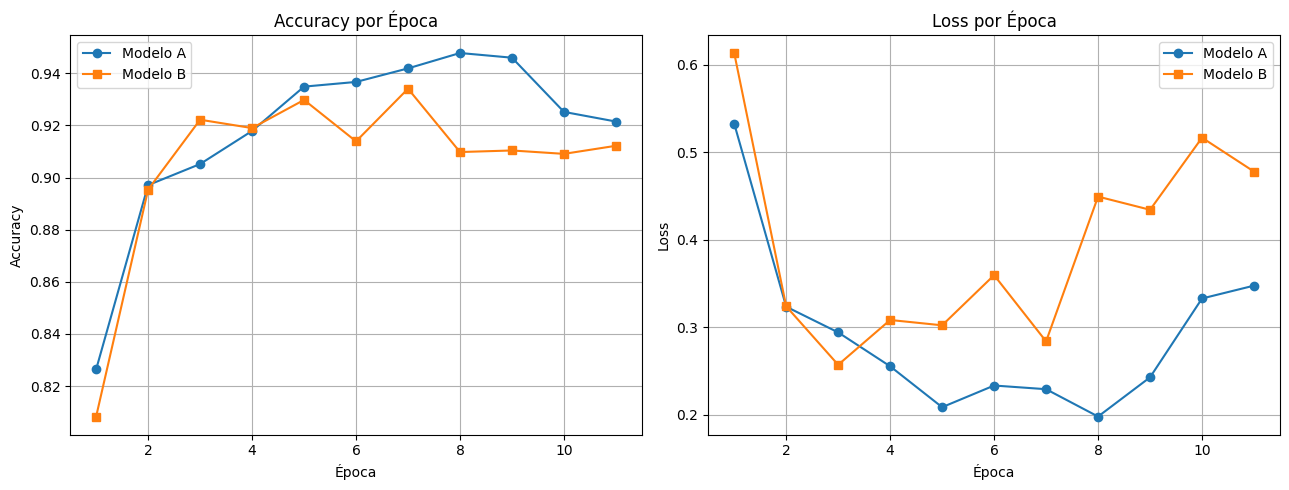

In [39]:
import matplotlib.pyplot as plt

epochs = list(range(1, 12)) #epoch extra que muestra el resultado del test set.

# Gráfico de Accuracy
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, First_try_acc, label='Modelo A', marker='o')
plt.plot(epochs, Res_Species_acc, label='Modelo B', marker='s')
plt.title('Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, First_try_loss, label='Modelo A', marker='o')
plt.plot(epochs, Res_Species_loss, label='Modelo B', marker='s')
plt.title('Loss por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()